In [1]:
import src.preprocessing as pp
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
from sklearn.metrics import root_mean_squared_error, r2_score
import matplotlib.pyplot as plt

Importamos los datos y los dividimos en conjunto de dev (entrenamiento y validacion) y test:

In [2]:
data = pd.read_csv(r'data/raw/alquiler_AMBA_dev.csv')
data = pp.preprocess(data)
print(data.shape)

C:\Users\03tom\AppData\Local\Temp\ipykernel_4800\3213428500.py:1: DtypeWarning: Columns (8,33,36) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(r'data/raw/alquiler_AMBA_dev.csv')


(274268, 22)


In [3]:
data_dev, data_test = train_test_split(data, test_size=5000/278725, random_state=42)
data_train, data_val = train_test_split(data_dev, test_size=0.2, random_state=42)

print(data_train.shape)
print(data_val.shape)
print(data_test.shape)

(215477, 22)
(53870, 22)
(4921, 22)


In [4]:
X_train = data_train.drop(columns=['precio_pesos_constantes'])
y_train = data_train['precio_pesos_constantes']
X_val = data_val.drop(columns=['precio_pesos_constantes'])
y_val = data_val['precio_pesos_constantes']
X_test = data_test.drop(columns=['precio_pesos_constantes'])
y_test = data_test['precio_pesos_constantes']

print(X_train.shape)
print(y_train.shape)
print(X_val.shape)
print(y_val.shape)
print(X_test.shape)
print(y_test.shape)

(215477, 21)
(215477,)
(53870, 21)
(53870,)
(4921, 21)
(4921,)


Tambien si bien algunos datos ya tienen transformaciones aplicadas, buscamos normalizar los datos para que tengan media 0 y desvio 1, para esto usamos la clase StandardScaler de sklearn

In [5]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

Creamos un modelo base, y lo evaluamos en el conjunto de datos de train y validación

In [6]:
model = xgb.XGBRegressor(n_estimators=500, 
                         learning_rate=0.05, 
                         max_depth=10, 
                         random_state=42, 
                         eval_metric='rmse', 
                         early_stopping_rounds=10, 
                         gamma=1, 
                         min_child_weight=1,
                         subsample=0.6)

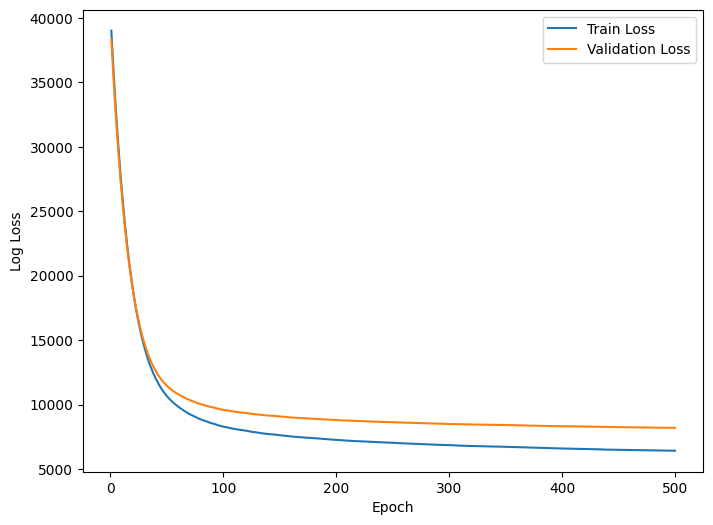

In [7]:
model.fit(X_train_scaled, y_train, eval_set=[(X_train_scaled, y_train), (X_val_scaled, y_val)], verbose=False)

results = model.evals_result()

epochs = range(1, len(results['validation_0']['rmse']) + 1)
plt.figure(figsize=(8, 6))
plt.plot(epochs, results['validation_0']['rmse'], label='Train Loss')
plt.plot(epochs, results['validation_1']['rmse'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Log Loss')
plt.legend()
plt.show()

In [8]:
y_train_pred = model.predict(X_train_scaled)
rmse = root_mean_squared_error(y_train, y_train_pred)
print('RMSE train:', rmse)
r2 = r2_score(y_train, y_train_pred)
print('R2 train:', r2)

RMSE train: 6421.61583811811
R2 train: 0.975148559094697


In [9]:
y_val_pred = model.predict(X_val_scaled)
rmse = root_mean_squared_error(y_val, y_val_pred)
print('RMSE val:', rmse)
r2 = r2_score(y_val, y_val_pred)
print('R2 val:', r2)

RMSE val: 8198.168723324367
R2 val: 0.9580869153323402


Ahora que tenemos un modelo base, intenetamos mejorar el rendimiento del modelo. Para ello, vamos a comenzar por buscar los hiperparámetros óptimos para el modelo (los que consideramos mas importantes):

In [ ]:
# CUIDADO CON ESTA CELDA, PUEDE TARDAR MUCHO EN EJECUTARSE!!! RECOMENDABLE NO CORRERLA
param_grid = {
    'n_estimators': [200, 500, 1000],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [7, 9, 12],
    'subsample': [0.8, 1.0],
    'gamma': [0, 1, 3],
    'min_child_weight': [1, 3]
}

grid_search = GridSearchCV(estimator=xgb.XGBRegressor(random_state=42), param_grid=param_grid, cv=2, scoring='neg_root_mean_squared_error', verbose=2)
grid_search.fit(X_train_scaled, y_train)

print(f'Best parameters: {grid_search.best_params_}')
print(f'Best RMSE: {grid_search.best_score_}')

Fitting 2 folds for each of 324 candidates, totalling 648 fits
[CV] END gamma=0, learning_rate=0.01, max_depth=7, min_child_weight=1, n_estimators=200, subsample=0.8; total time=   1.2s
[CV] END gamma=0, learning_rate=0.01, max_depth=7, min_child_weight=1, n_estimators=200, subsample=0.8; total time=   1.1s
[CV] END gamma=0, learning_rate=0.01, max_depth=7, min_child_weight=1, n_estimators=200, subsample=1.0; total time=   0.9s
[CV] END gamma=0, learning_rate=0.01, max_depth=7, min_child_weight=1, n_estimators=200, subsample=1.0; total time=   0.9s
[CV] END gamma=0, learning_rate=0.01, max_depth=7, min_child_weight=1, n_estimators=500, subsample=0.8; total time=   2.6s
[CV] END gamma=0, learning_rate=0.01, max_depth=7, min_child_weight=1, n_estimators=500, subsample=0.8; total time=   2.6s
[CV] END gamma=0, learning_rate=0.01, max_depth=7, min_child_weight=1, n_estimators=500, subsample=1.0; total time=   2.4s
[CV] END gamma=0, learning_rate=0.01, max_depth=7, min_child_weight=1, n_est

Una vez que tengamos los hiperparámetros óptimos, vamos a hacer cross-validation para evaluar el rendimiento del modelo de una manera más robusta:

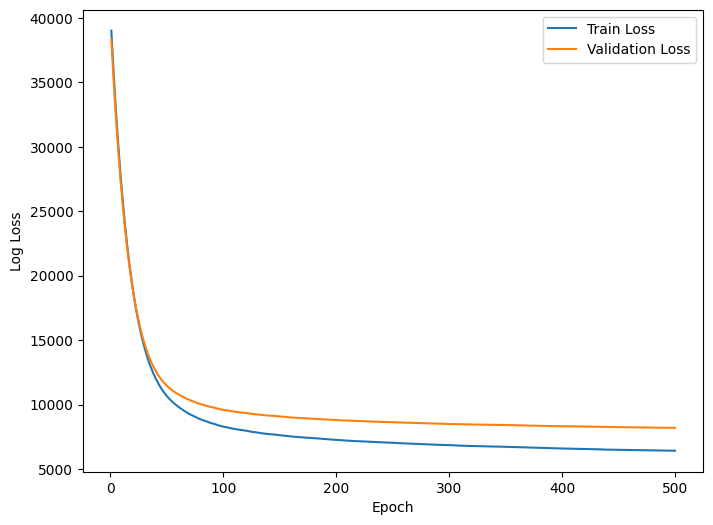

In [10]:
best_model = xgb.XGBRegressor(
    gamma=0,
    learning_rate=0.1,
    max_depth=9,
    min_child_weight=1,
    n_estimators=1000,
    subsample=1.0,
    random_state=42
)

best_model.fit(X_train_scaled, y_train, eval_set=[(X_train_scaled, y_train), (X_val_scaled, y_val)], verbose=False)
best_results = best_model.evals_result()

epochs = range(1, len(results['validation_0']['rmse']) + 1)
plt.figure(figsize=(8, 6))
plt.plot(epochs, results['validation_0']['rmse'], label='Train Loss')
plt.plot(epochs, results['validation_1']['rmse'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Log Loss')
plt.legend()
plt.show()

In [11]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_score_train_rmse = cross_val_score(best_model, X_train_scaled, y_train, cv=kf, scoring='neg_root_mean_squared_error')
cv_score_train_r2 = cross_val_score(best_model, X_train_scaled, y_train, cv=kf, scoring='r2')
print(f'Cross-validation RMSE (5-fold): {cv_score_train_rmse}')
print(f'Promedio RMSE de CV: {-cv_score_train_rmse.mean()}')
print(f'Cross-validation R2 (5-fold): {cv_score_train_r2}')
print(f'Promedio R2 de CV: {cv_score_train_r2.mean()}')

cv_score_val_rmse = cross_val_score(best_model, X_val_scaled, y_val, cv=kf, scoring='neg_root_mean_squared_error')
cv_score_val_r2 = cross_val_score(best_model, X_val_scaled, y_val, cv=kf, scoring='r2')
print(f'Cross-validation RMSE (5-fold): {cv_score_val_rmse}')
print(f'Promedio RMSE de CV: {-cv_score_val_rmse.mean()}')
print(f'Cross-validation R2 (5-fold): {cv_score_val_r2}')
print(f'Promedio R2 de CV: {cv_score_val_r2.mean()}')

Cross-validation RMSE (5-fold): [-7660.97715875 -7511.71559215 -8464.64958508 -7763.28218091
 -7614.16304555]
Promedio RMSE de CV: 7802.957512490345
Cross-validation R2 (5-fold): [0.96488489 0.96586933 0.95820236 0.9638895  0.96350702]
Promedio R2 de CV: 0.9632706189896119
Cross-validation RMSE (5-fold): [-11969.52785518 -11863.4386908  -12579.66950139 -12275.55252183
 -11775.53092562]
Promedio RMSE de CV: 12092.74389896496
Cross-validation R2 (5-fold): [0.91356464 0.9116685  0.90191119 0.90563729 0.91090544]
Promedio R2 de CV: 0.9087374104445857


Finalmente, simulamos un set de test para evaluar el rendimiento del modelo en datos no vistos

In [12]:
y_test_pred = best_model.predict(X_test_scaled)
rmse = root_mean_squared_error(y_test, y_test_pred)
print('RMSE test:', rmse)
r2 = r2_score(y_test, y_test_pred)
print('R2 test:', r2)

RMSE test: 6943.798346453657
R2 test: 0.9678606687915812


Por ultimo, predecimos los valores de todo el dataset para usarlos posteriormente en la extension:

In [13]:
X_scaled = scaler.transform(data.drop(columns=['precio_pesos_constantes']))
y_pred = best_model.predict(X_scaled)
print('R2 de todo el dataset:', r2_score(data['precio_pesos_constantes'], y_pred))

predictions_df = pd.DataFrame({'predicted_price': y_pred})
predictions_df.to_csv(r'data/data_predictions.csv', index=True)
print(predictions_df.shape)
print("Predicciones guardadas en 'data_predictions.csv'")

R2 de todo el dataset: 0.9805940037807008
(274268, 1)
Predicciones guardadas en 'data_predictions.csv'


y hacemos sus respectivos graficos de residuos y pred vs dato:

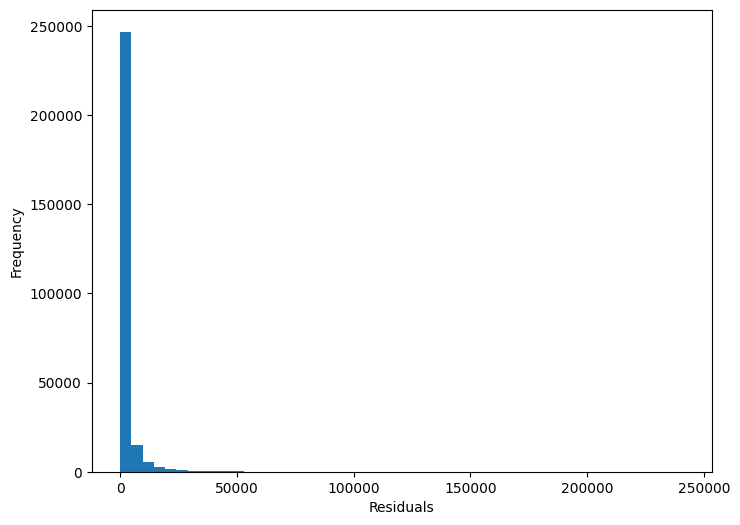

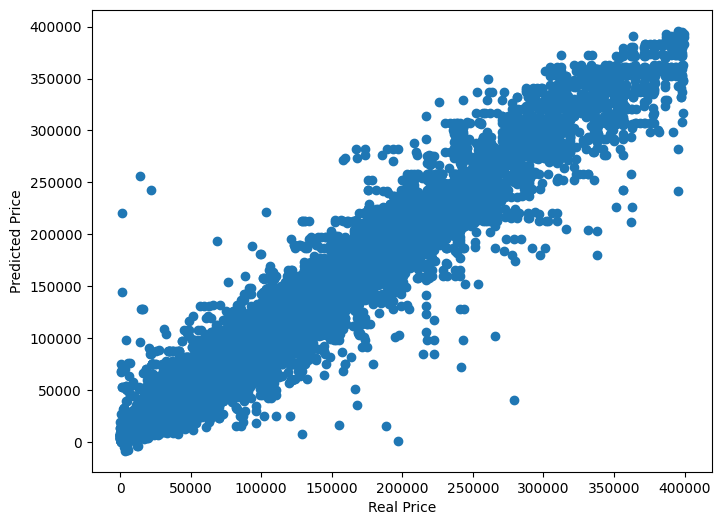

In [14]:
residuals = abs(y_pred - data['precio_pesos_constantes'])
plt.figure(figsize=(8, 6))
plt.hist(residuals, bins=50)
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(8, 6))
plt.scatter(data['precio_pesos_constantes'], y_pred)
plt.xlabel('Real Price')
plt.ylabel('Predicted Price')
plt.show()

Ahora, con la implementacion del modelo ya completada, tomamos el set de test que nos da la catedra y generamos sus predicciones:

In [15]:
X_newTest = pd.read_csv(r'data/raw/alquiler_AMBA_test.csv')
ids = X_newTest['id']

X_newTest = pd.read_csv(r'data/processed/test_preprocessed.csv')
X_newTest_scaled = scaler.transform(X_newTest)
print(X_test.shape)

(4921, 21)


In [17]:
newTest_pred = best_model.predict(X_newTest_scaled)
test_predictions_df = pd.DataFrame({
    'id': ids,
    'predicted_price': newTest_pred
})

test_predictions_df.to_csv(r'data/Diaz_ModelXGB_predictions.csv', index=False)

print(test_predictions_df.shape)
print("Predicciones guardadas en 'Diaz_ModelXGB_predictions.csv'")

(30481, 2)
Predicciones guardadas en 'Diaz_ModelXGB_predictions.csv'
